In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 统一调用共享的信号/噪声工具函数
try:
    from dataset.signal_generators import *
except ModuleNotFoundError:
    from signal_generators import *


def save_multivariate_signal(signals, feature_names, folder, signal_name, dataset_id=None, category=None, length=None):
    """保存多变量信号到 CSV。"""
    if not os.path.exists(folder):
        os.makedirs(folder)

    filename = signal_name
    if dataset_id is not None:
        filename = f"dataset{dataset_id}_{filename}"
    if category is not None:
        filename = f"{filename}_{category}"
    if length is not None:
        filename = f"{filename}_length{length}"

    timestamps = np.arange(len(signals[0]))
    data = {"date": timestamps}
    for series, name in zip(signals, feature_names):
        data[name] = series

    pd.DataFrame(data).to_csv(os.path.join(folder, f"{filename}.csv"), index=False)


def plot_multivariate_signals(signal_data_dict, n_samples_to_plot=1000):
    """可视化多变量信号（用于快速查看生成结果）。"""
    if not signal_data_dict:
        return

    plt.figure(figsize=(15, 5 * len(signal_data_dict)))
    for idx, (name, signals) in enumerate(signal_data_dict.items(), 1):
        plt.subplot(len(signal_data_dict), 1, idx)
        if isinstance(signals, (tuple, list)):
            for j, series in enumerate(signals, 1):
                plt.plot(series[:n_samples_to_plot], label=f"Feature {j}")
        else:
            plt.plot(signals[:n_samples_to_plot], label=name)
        plt.title(name)
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()



In [6]:
# ---------------------------------------------
# 基础多变量关系（来自 multivariate-relationship）
# ---------------------------------------------

def generate_lagged_features(n, lag_window=10, noise_std=1):
    feature_a = generate_white_noise(n, mean=0, std=noise_std)
    feature_b = np.zeros(n)
    feature_b[lag_window:] = feature_a[:-lag_window]
    return feature_a, feature_b


def generate_sin_noise_composite(n, sin_frequency=0.05, sin_amplitude=1, noise_snr_db=0):
    feature_a = generate_sine_wave(n, amplitude=sin_amplitude, frequency=sin_frequency)
    signal_power = np.var(feature_a)
    noise_power = signal_power / (10 ** (noise_snr_db / 10))
    noise_std = np.sqrt(noise_power)
    feature_b = generate_white_noise(n, std=noise_std)
    feature_c = feature_a + feature_b
    return feature_a, feature_b, feature_c


def generate_basic_multivariate_sets(n, dataset_folder, dataset_id):
    """生成滞后特征与正弦噪声组合数据集。"""
    lag_signals = {}
    for lag in [5, 10, 24, 48]:
        feature_a, feature_b = generate_lagged_features(n, lag_window=lag)
        signal_name = f"Lag{lag}"
        lag_signals[signal_name] = (feature_a, feature_b)
        save_multivariate_signal(
            [feature_a, feature_b],
            ["FeatureA_WhiteNoise", f"FeatureB_Lag{lag}"],
            dataset_folder,
            signal_name,
            dataset_id,
            "raw",
            n,
        )

    # 正弦+噪声组合
    feature_a, feature_b, feature_c = generate_sin_noise_composite(n, 0.05, 1, 0)
    save_multivariate_signal(
        [feature_a, feature_b, feature_c],
        ["FeatureA_Sin", "FeatureB_Noise_0dB", "FeatureC_Sum"],
        dataset_folder,
        "SinNoiseComposite",
        dataset_id,
        "raw",
        n,
    )

    return lag_signals, {"SinNoiseComposite": (feature_a, feature_b, feature_c)}



In [7]:
# ---------------------------------------------
# 复杂关系（来自 multivariate-complex-relationship）
# ---------------------------------------------

def generate_nonlinear_relationship(n, lag=48, a=2.0, b=0.5, noise_std=0.1, x_noise_std=1.0):
    X = np.random.normal(0, x_noise_std, n)
    Y = np.zeros(n)
    for t in range(lag, n):
        Y[t] = a * np.sin(b * X[t - lag]) + np.random.normal(0, noise_std)
    mean_y = np.mean(Y[lag:])
    Y[:lag] = np.random.normal(mean_y, noise_std, lag)
    return X, Y


def generate_conditional_relationship(n, lag=48, threshold=0.0, x_noise_std=1.0, noise_prob=0.05):
    X = np.random.normal(0, x_noise_std, n)
    Y = np.zeros(n)
    for t in range(lag, n):
        Y[t] = 1 if X[t - lag] > threshold else 0
        if np.random.random() < noise_prob:
            Y[t] = 1 - Y[t]
    Y[:lag] = np.random.choice([0, 1], size=lag, p=[0.5, 0.5])
    return X, Y


def generate_multivariable_complex(n, lag1=24, lag2=48, noise_std=0.1):
    V1 = np.random.normal(0, 1, n)
    V2 = np.zeros(n)
    V3 = np.zeros(n)
    V4 = np.zeros(n)
    V5 = np.zeros(n)

    for t in range(lag1, n):
        V2[t] = 0.8 * V1[t - lag1] + np.random.normal(0, noise_std)
    V2[:lag1] = np.random.normal(0, 0.8, lag1)

    lag_12 = 12
    for t in range(lag_12, n):
        V3[t] = np.sin(V1[t - lag_12]) * np.cos(V2[t - lag_12]) + np.random.normal(0, noise_std)
    V3[:lag_12] = np.random.normal(0, 0.5, lag_12)

    v2_median = np.median(V2)
    for t in range(lag1, n):
        V4[t] = 1 if V2[t - lag1] > v2_median else 0
        if np.random.random() < 0.05:
            V4[t] = 1 - V4[t]
    V4[:lag1] = np.random.choice([0, 1], size=lag1)

    lag_6 = 6
    for t in range(lag_6, n):
        base = V1[t - lag_6] + 0.5 * V3[t - lag_6]
        conditional = V4[t - lag_6] * np.sign(V1[t - lag_6]) * 0.3
        V5[t] = base + conditional + np.random.normal(0, noise_std)
    V5[:lag_6] = np.random.normal(0, 1, lag_6)

    return V1, V2, V3, V4, V5


def generate_complex_multivariate_sets(n, dataset_folder, dataset_id):
    """生成非线性、条件与复杂交互数据集。"""
    X_nonlin, Y_nonlin = generate_nonlinear_relationship(n)
    save_multivariate_signal(
        [X_nonlin, Y_nonlin],
        ["X_WhiteNoise", "Y_NonlinearSin"],
        dataset_folder,
        "NonlinearRelationship",
        dataset_id,
        "raw",
        n,
    )

    X_cond, Y_cond = generate_conditional_relationship(n)
    save_multivariate_signal(
        [X_cond, Y_cond],
        ["X_WhiteNoise", "Y_BinaryConditional"],
        dataset_folder,
        "ConditionalRelationship",
        dataset_id,
        "raw",
        n,
    )

    V1, V2, V3, V4, V5 = generate_multivariable_complex(n)
    save_multivariate_signal(
        [V1, V2, V3, V4, V5],
        [
            "V1_WhiteNoise",
            "V2_LinearLag",
            "V3_NonlinearInteraction",
            "V4_BinaryConditional",
            "V5_ComplexInteraction",
        ],
        dataset_folder,
        "MultivariableComplex",
        dataset_id,
        "raw",
        n,
    )

    return {
        "NonlinearRelationship": (X_nonlin, Y_nonlin),
        "ConditionalRelationship": (X_cond, Y_cond),
        "MultivariableComplex": (V1, V2, V3, V4, V5),
    }




>>> Generating dataset 1 with seed 0


Plotting sample signals...


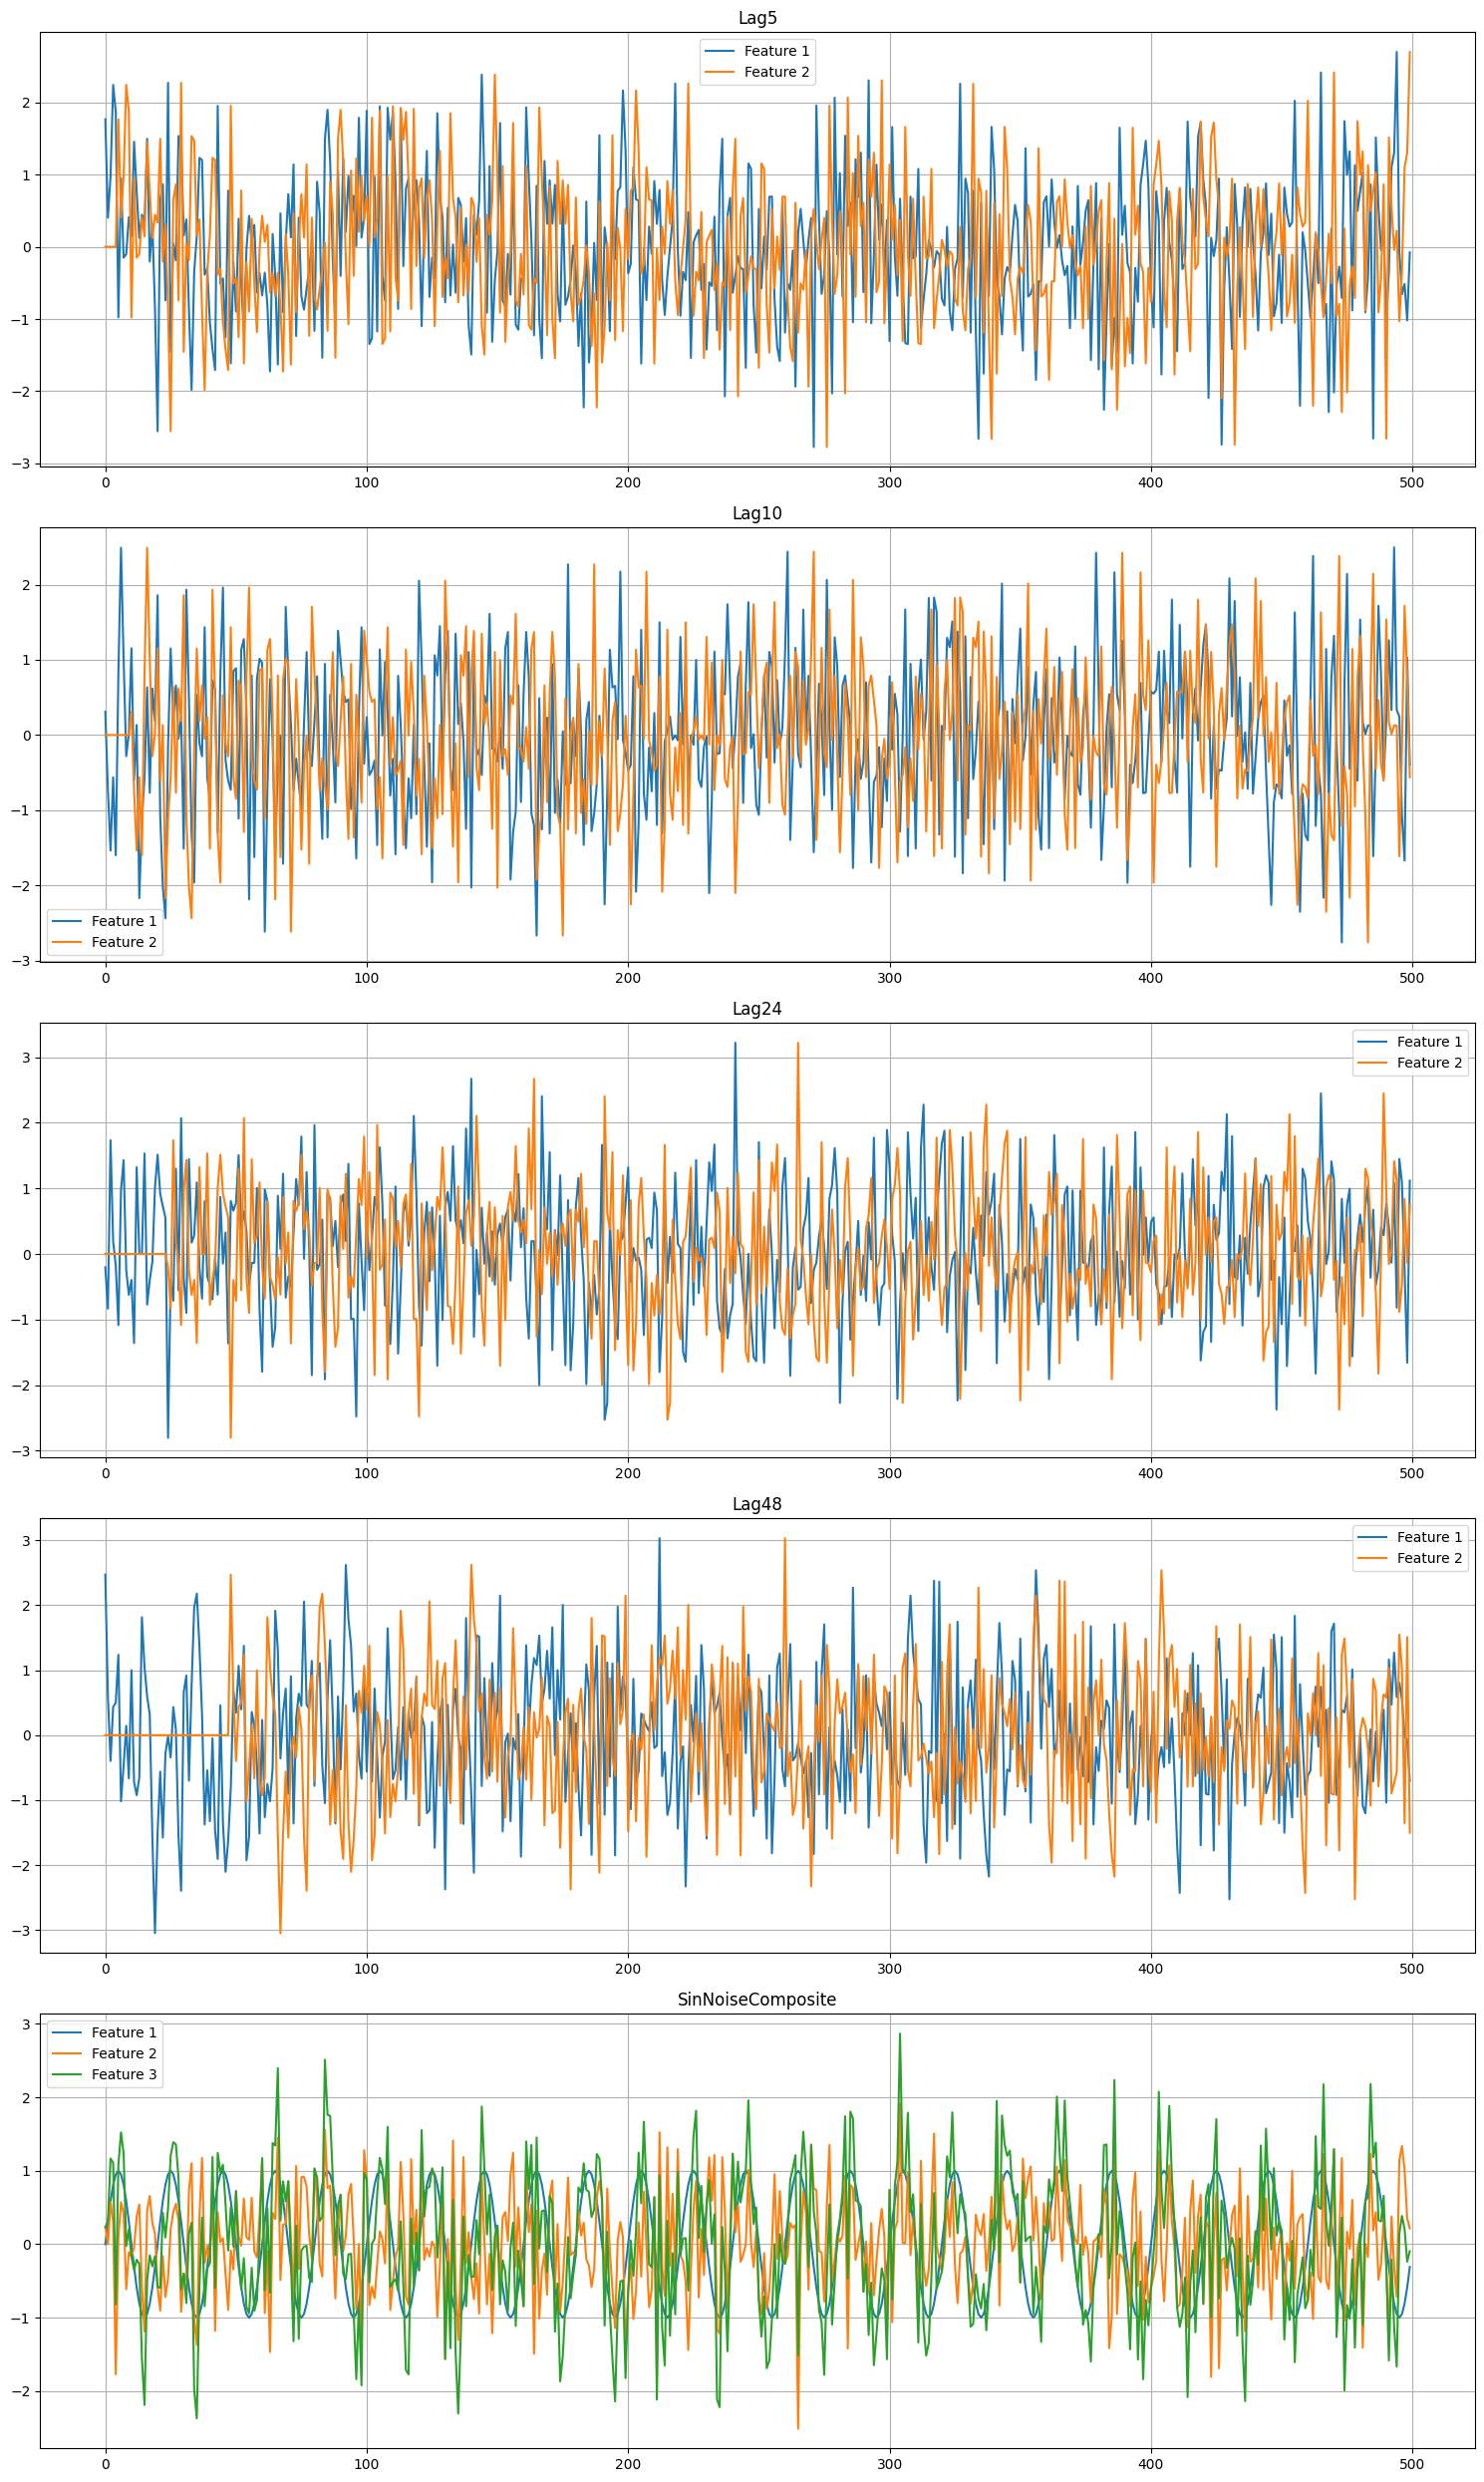

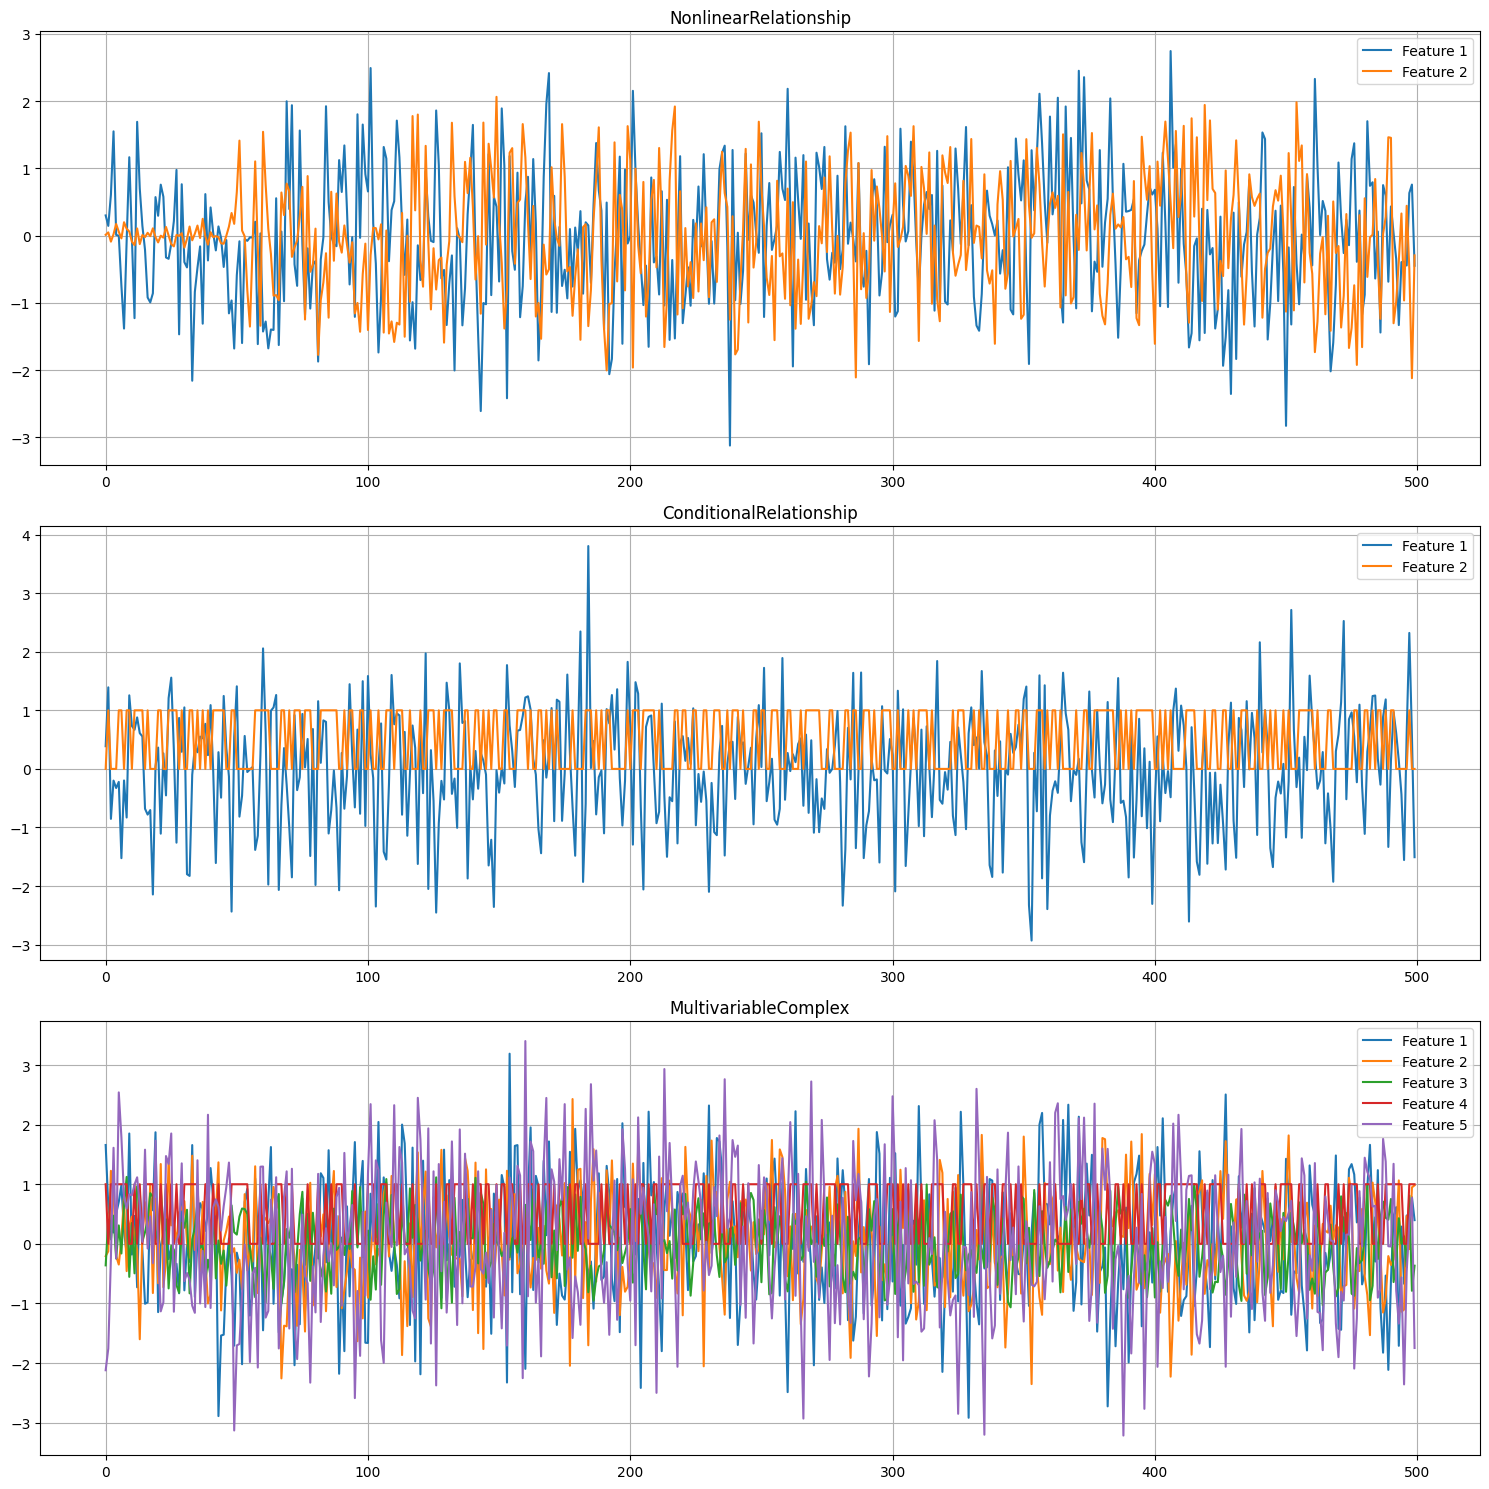


All 1 datasets saved to Dataset_generated_multivariate


In [9]:
# ---------------------------------------------
# 统一调度 & 批量生成
# ---------------------------------------------

def generate_and_save_all_multivariate_datasets(seed, dataset_folder, dataset_id, n=5000, visualize=True):
    np.random.seed(seed)
    print(f"\n>>> Generating dataset {dataset_id} with seed {seed}")

    basic_signals, composite_signals = generate_basic_multivariate_sets(n, dataset_folder, dataset_id)
    complex_signals = generate_complex_multivariate_sets(n, dataset_folder, dataset_id)

    if visualize:
        print("Plotting sample signals...")
        plot_multivariate_signals({**basic_signals, **composite_signals}, n_samples_to_plot=500)
        plot_multivariate_signals(complex_signals, n_samples_to_plot=500)


def generate_multiple_datasets(num_datasets=3, output_folder="Dataset_generated_multivariate", base_seed=None, n=5000, visualize=True):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for i in range(num_datasets):
        seed = base_seed + i if base_seed is not None else i
        generate_and_save_all_multivariate_datasets(seed, output_folder, i + 1, n=n, visualize=visualize)

    print(f"\nAll {num_datasets} datasets saved to {output_folder}")


if __name__ == "__main__":
    generate_multiple_datasets(num_datasets=1, visualize=True)

